# **Sprint 11**
## Hecho por DA: *Mau Vilar*
### https://github.com/mauvilar

### --> Preparación del dataset

In [53]:
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns

## Paso 1. Abrir el archivo de datos y leer la información general

In [54]:
logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

print('Shape:', logs.shape)
logs.head()

Shape: (244126, 4)


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [55]:
print('\n=== info logs ===\n')
logs.info()


=== info logs ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


## Paso 2. Preparar los datos para el análisis

### --> Ajuste de columnas (snake_case y datetime)

In [56]:
# Renombrar columnas

logs = logs.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'exp_id'
})

print('\n=== columnas renombradas (head) ===\n')
logs.head()


=== columnas renombradas (head) ===



,event_name,user_id,event_timestamp,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [57]:
# Convertir timestamp (segundos) a datetime

logs['event_datetime'] = pd.to_datetime(logs['event_timestamp'], unit='s')

# Solo la fecha
logs['event_date'] = logs['event_datetime'].dt.date

print('\n=== head con columnas de fecha ===\n')
logs.head()



=== head con columnas de fecha ===



,event_name,user_id,event_timestamp,exp_id,event_datetime,event_date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


In [58]:
print('\n=== Info logs después de preparar fechas ===\n')
logs.info()


=== Info logs después de preparar fechas ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       244126 non-null  object        
 1   user_id          244126 non-null  int64         
 2   event_timestamp  244126 non-null  int64         
 3   exp_id           244126 non-null  int64         
 4   event_datetime   244126 non-null  datetime64[ns]
 5   event_date       244126 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 11.2+ MB


### --> Revisión de duplicados

In [59]:
print('\n=== Duplicados ===')

# Número de filas duplicadas
dup_rows = logs.duplicated().sum()
print('Filas duplicadas:', dup_rows)

# Si hay duplicados, los eliminamos
if dup_rows > 0:
    logs = logs.drop_duplicates().reset_index(drop=True)
    print('Nuevas dimensiones después de drop_duplicates:', logs.shape)


=== Duplicados ===
Filas duplicadas: 413
Nuevas dimensiones después de drop_duplicates: (243713, 6)


In [60]:
print('\n=== Info logs sin duplicados ===\n')
logs.info()


=== Info logs sin duplicados ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243713 entries, 0 to 243712
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       243713 non-null  object        
 1   user_id          243713 non-null  int64         
 2   event_timestamp  243713 non-null  int64         
 3   exp_id           243713 non-null  int64         
 4   event_datetime   243713 non-null  datetime64[ns]
 5   event_date       243713 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 11.2+ MB


In [61]:
# Ajuste de exp_id para los grupos de control y grupo de prueba

logs['group'] = logs['exp_id'].map({
    246: 'A1_control',
    247: 'A2_control',
    248: 'B_test'
})

In [62]:
print('\n=== Info logs preparados ===\n')
logs.info()


=== Info logs preparados ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243713 entries, 0 to 243712
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       243713 non-null  object        
 1   user_id          243713 non-null  int64         
 2   event_timestamp  243713 non-null  int64         
 3   exp_id           243713 non-null  int64         
 4   event_datetime   243713 non-null  datetime64[ns]
 5   event_date       243713 non-null  object        
 6   group            243713 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 13.0+ MB


## Paso 3. Estudiar y comprobar los datos

In [63]:
# ¿Cuántos eventos hay? 

n_events = len(logs)
print("\n=== Número de eventos ===")
print(f'--> {n_events}')


# ¿Cuántos usuarios únicos?

n_users = logs['user_id'].nunique()
print("\n=== Número de usuarios únicos ===")
print(f'--> {n_users}')

# Promedio de eventos por usuario

events_per_user = n_events / n_users
print("\n=== Promedio de eventos por usuario ===")
print(f'--> {events_per_user:.3f}')



=== Número de eventos ===
--> 243713

=== Número de usuarios únicos ===
--> 7551

=== Promedio de eventos por usuario ===
--> 32.276


### --> Rango de tiempo

In [64]:
print('\n=== Rango de fechas (event_datetime) ===\n')
print('Mínimo:', logs['event_datetime'].min())
print('Máximo:', logs['event_datetime'].max())


=== Rango de fechas (event_datetime) ===

Mínimo: 2019-07-25 04:43:36
Máximo: 2019-08-07 21:15:17


### --> Eventos por día


=== Eventos por fecha ===
event_date
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      412
2019-07-31     2030
2019-08-01    36141
2019-08-02    35554
2019-08-03    33282
2019-08-04    32968
2019-08-05    36058
2019-08-06    35788
2019-08-07    31096
dtype: int64


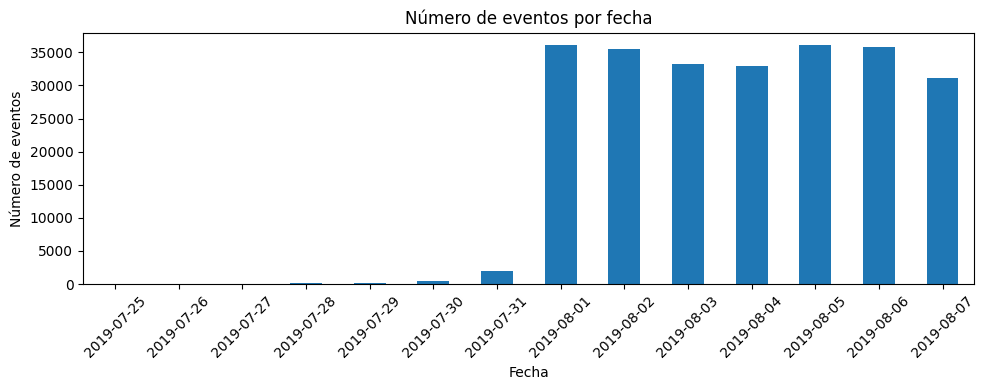

In [65]:
events_by_date = logs.groupby('event_date').size()

print('\n=== Eventos por fecha ===')
print(events_by_date)

plt.figure(figsize=(10, 4))
events_by_date.plot(kind='bar')
plt.title('Número de eventos por fecha')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [66]:
# Período representativo de la gráfica

cut_date = pd.to_datetime('2019-08-01').date()

logs_filtered = logs[logs['event_date'] >= cut_date].copy()

print('\n=== Comparación antes y después del corte ===\n')
print('Eventos totales     :', len(logs))
print('Eventos filtrados   :', len(logs_filtered))
print('Eventos perdidos    :', len(logs) - len(logs_filtered))

print('\nUsuarios totales    :', logs['user_id'].nunique())
print('Usuarios filtrados  :', logs_filtered['user_id'].nunique())
print('Usuarios perdidos   :', logs['user_id'].nunique() - logs_filtered['user_id'].nunique())



=== Comparación antes y después del corte ===

Eventos totales     : 243713
Eventos filtrados   : 240887
Eventos perdidos    : 2826

Usuarios totales    : 7551
Usuarios filtrados  : 7534
Usuarios perdidos   : 17


In [67]:
logs = logs_filtered

print('\n=== info logs (periodo filtrado) ===')
logs.info()


=== info logs (periodo filtrado) ===
<class 'pandas.core.frame.DataFrame'>
Int64Index: 240887 entries, 2826 to 243712
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       240887 non-null  object        
 1   user_id          240887 non-null  int64         
 2   event_timestamp  240887 non-null  int64         
 3   exp_id           240887 non-null  int64         
 4   event_datetime   240887 non-null  datetime64[ns]
 5   event_date       240887 non-null  object        
 6   group            240887 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 14.7+ MB


### Análisis

- El dataset original contiene **243,713 eventos** de **7,551 usuarios**, con un promedio de **32.3 eventos por usuario**.
- Los eventos abarcan del **25-07-2019** al **07-08-2019**. Sin embargo, del 25-07 al 31-07 el número de eventos por día es muy bajo, mientras que del **01-08-2019** al 07-08-2019 el volumen diario se estabiliza (33k–36k eventos por día).
- Para evitar sesgos debidos a datos incompletos, utilizo solo los eventos a partir del **01-08-2019**. Tras aplicar este filtro, quedan **240,887 eventos** y **7,534 usuarios**, es decir, se pierden solo **2,826 eventos (1.2%)** y **17 usuarios (0.2%)**. El impacto del corte es mínimo y los datos filtrados representan mejor la actividad real de la aplicación.


## Paso 4. Estudiar el embudo de eventos

In [68]:
print('\n=== Frecuencia total de eventos (event_name) ===')
events_counts = logs['event_name'].value_counts()
print(events_counts)

print('\n=== Usuarios únicos por evento ===')
users_per_event = (
    logs.groupby('event_name')['user_id']
        .nunique()
        .sort_values(ascending=False)
)
print(users_per_event)

print('\n=== Proporción de usuarios por evento ===')
n_users_filtered = logs['user_id'].nunique()
users_share = (users_per_event / n_users_filtered).round(3)
print(users_share)



=== Frecuencia total de eventos (event_name) ===
MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64

=== Usuarios únicos por evento ===
event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: user_id, dtype: int64

=== Proporción de usuarios por evento ===
event_name
MainScreenAppear           0.985
OffersScreenAppear         0.610
CartScreenAppear           0.496
PaymentScreenSuccessful    0.470
Tutorial                   0.111
Name: user_id, dtype: float64


### Interpretación
- Casi todos los usuarios ven la pantalla principal (esperado, es el punto de entrada).

- Solo 61% llegan a la pantalla de ofertas.

- ~50% llegan al carrito.

- 47% completan un pago exitoso al menos una vez.

- Solo 11% ven el tutorial --> no parece obligatorio.

### --> Conversión entre etapas del embudo

In [69]:
print('\n=== Embudo de eventos (usuarios únicos por etapa) ===')

funnel_events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

funnel_users = users_per_event.loc[funnel_events]
print(funnel_users)

# Conversión paso a paso
step_conversion = (funnel_users / funnel_users.shift(1)).round(3)
step_conversion.iloc[0] = 1.0  # primera etapa = 100% de sí misma

print('\n=== Conversión entre etapas (relativa a la etapa anterior) ===')
print(step_conversion)

# Conversión acumulada desde la primera etapa
overall_conversion = (funnel_users / funnel_users.iloc[0]).round(3)
print('\n=== Conversión acumulada desde MainScreenAppear ===')
print(overall_conversion)



=== Embudo de eventos (usuarios únicos por etapa) ===
event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Name: user_id, dtype: int64

=== Conversión entre etapas (relativa a la etapa anterior) ===
event_name
MainScreenAppear           1.000
OffersScreenAppear         0.619
CartScreenAppear           0.813
PaymentScreenSuccessful    0.948
Name: user_id, dtype: float64

=== Conversión acumulada desde MainScreenAppear ===
event_name
MainScreenAppear           1.000
OffersScreenAppear         0.619
CartScreenAppear           0.503
PaymentScreenSuccessful    0.477
Name: user_id, dtype: float64


### Análisis

- El embudo principal de la aplicación sigue la secuencia:
  `MainScreenAppear -> OffersScreenAppear -> CartScreenAppear -> PaymentScreenSuccessful`.
- Casi todos los usuarios ven la pantalla principal (**98.5%**), pero solo
  **61–62%** de ellos llegan a la pantalla de ofertas. A partir de ahí, el embudo es más eficiente:
  **81%** de quienes ven ofertas pasan al carrito y **95%** de quienes llegan al carrito
  completan un pago exitoso.
- En términos acumulados, alrededor de **48%** de los usuarios que ven la pantalla principal
  completan al menos un pago exitoso.
- La mayor pérdida de usuarios ocurre en la transición **de la pantalla principal a la pantalla de ofertas**.



## Paso 5. Estudiar los resultados del experimento

In [70]:
print('\n=== Número de usuarios por grupo ===')

group_users = (
    logs.groupby('group')['user_id']
        .nunique()
        .sort_index()
)
print(group_users)



=== Número de usuarios por grupo ===
group
A1_control    2484
A2_control    2513
B_test        2537
Name: user_id, dtype: int64


In [71]:
print('\n=== Usuarios únicos por evento y grupo ===')

users_by_event_group = (
    logs.groupby(['event_name', 'group'])['user_id']
        .nunique()
        .unstack('group')      # columnas = grupos
        .fillna(0)
        .astype(int)
)

print(users_by_event_group)

print('\n=== Proporción de usuarios por evento y grupo ===')

users_share_by_event_group = (
    users_by_event_group
    .div(group_users, axis=1)   # divide cada columna por los usuarios del grupo
    .round(3)
)

print(users_share_by_event_group)



=== Usuarios únicos por evento y grupo ===
group                    A1_control  A2_control  B_test
event_name                                             
CartScreenAppear               1266        1238    1230
MainScreenAppear               2450        2476    2493
OffersScreenAppear             1542        1520    1531
PaymentScreenSuccessful        1200        1158    1181
Tutorial                        278         283     279

=== Proporción de usuarios por evento y grupo ===
group                    A1_control  A2_control  B_test
event_name                                             
CartScreenAppear              0.510       0.493   0.485
MainScreenAppear              0.986       0.985   0.983
OffersScreenAppear            0.621       0.605   0.603
PaymentScreenSuccessful       0.483       0.461   0.466
Tutorial                      0.112       0.113   0.110


### --> Test A/A y A/B (z-test de proporciones)

In [76]:
alpha = 0.05

def test_event_between_groups(event_name, group_a, group_b):
    successes = np.array(
        users_by_event_group.loc[event_name, [group_a, group_b]].values
    )
    nobs = np.array(
        group_users.loc[[group_a, group_b]].values
    )

    
    # proporciones observadas
    p1 = successes[0] / nobs[0]
    p2 = successes[1] / nobs[1]

    # proporción combinada
    p_combined = successes.sum() / nobs.sum()

    # diferencia de proporciones
    diff = p1 - p2

    # error estándar
    se = np.sqrt(p_combined * (1 - p_combined) * (1 / nobs[0] + 1 / nobs[1]))

    # estadístico z
    z_value = diff / se

    # p-valor bilateral
    p_value = (1 - st.norm.cdf(abs(z_value))) * 2

    return z_value, p_value

### --> Test A/A 
#### A1 vs A2

In [75]:
alpha = 0.05

# MainScreenAppear
z_main, p_main = test_event_between_groups('MainScreenAppear',
                                           'A1_control', 'A2_control')
print('MainScreenAppear | A1 vs A2')
print(f'z = {z_main:.3f}, p = {p_main:.4f}')
print('Conclusión:',
      'rechazamos H0' if p_main < alpha else 'no rechazamos H0')

# OffersScreenAppear
z_offers, p_offers = test_event_between_groups('OffersScreenAppear',
                                               'A1_control', 'A2_control')
print('\nOffersScreenAppear | A1 vs A2')
print(f'z = {z_offers:.3f}, p = {p_offers:.4f}')
print('Conclusión:',
      'rechazamos H0' if p_offers < alpha else 'no rechazamos H0')

# CartScreenAppear
z_cart, p_cart = test_event_between_groups('CartScreenAppear',
                                           'A1_control', 'A2_control')
print('\nCartScreenAppear | A1 vs A2')
print(f'z = {z_cart:.3f}, p = {p_cart:.4f}')
print('Conclusión:',
      'rechazamos H0' if p_cart < alpha else 'no rechazamos H0')

# PaymentScreenSuccessful
z_pay, p_pay = test_event_between_groups('PaymentScreenSuccessful',
                                         'A1_control', 'A2_control')


print('\nPaymentScreenSuccessful | A1 vs A2')
print(f'z = {z_pay:.3f}, p = {p_pay:.4f}')
print('Conclusión:',
      'rechazamos H0' if p_pay < alpha else 'no rechazamos H0')


MainScreenAppear | A1 vs A2
z = 0.309, p = 0.7571
Conclusión: no rechazamos H0

OffersScreenAppear | A1 vs A2
z = 1.155, p = 0.2481
Conclusión: no rechazamos H0

CartScreenAppear | A1 vs A2
z = 1.203, p = 0.2288
Conclusión: no rechazamos H0

PaymentScreenSuccessful | A1 vs A2
z = 1.578, p = 0.1146
Conclusión: no rechazamos H0


### --> Test A/B
#### A1 vs B

In [77]:
z_pay_AB, p_pay_AB = test_event_between_groups('PaymentScreenSuccessful',
                                               'A1_control', 'B_test')
print('\nPaymentScreenSuccessful | A1 vs B')
print(f'z = {z_pay_AB:.3f}, p = {p_pay_AB:.4f}')
print('Conclusión:',
      'rechazamos H0' if p_pay_AB < alpha else 'no rechazamos H0')



PaymentScreenSuccessful | A1 vs B
z = 1.247, p = 0.2123
Conclusión: no rechazamos H0


#### A2 vs B

In [78]:
z_pay_AB2, p_pay_AB2 = test_event_between_groups(
    'PaymentScreenSuccessful',
    'A2_control', 'B_test'
)

print('\nPaymentScreenSuccessful | A2 vs B')
print(f'z = {z_pay_AB2:.3f}, p = {p_pay_AB2:.4f}')
print('Conclusión:',
      'rechazamos H0' if p_pay_AB2 < alpha else 'no rechazamos H0')



PaymentScreenSuccessful | A2 vs B
z = -0.335, p = 0.7373
Conclusión: no rechazamos H0


## **Conclusiones del experimento --> A/A/B**

- Los tres grupos tienen tamaños similares: 2.5k usuarios cada uno.
- En el test A/A (A1 vs A2), para los cuatro eventos analizados
  (`MainScreenAppear`, `OffersScreenAppear`, `CartScreenAppear`,
  `PaymentScreenSuccessful`) todas las p-values son mayores a 0.05.
  No se detectan diferencias significativas → los grupos de control se
  consideran equivalentes.
- En el test A/B, al comparar la proporción de usuarios que completan
  `PaymentScreenSuccessful` entre los grupos A (control) y B (fuentes nuevas),
  las p-values también son mayores a 0.05.
  No hay evidencia estadística de que el cambio de fuentes afecte la conversión.


## **Nivel de significancia y número de pruebas**

- En total realicé 6 pruebas de hipótesis:
  - 4 pruebas A/A (A1 vs A2) para los eventos:
    `MainScreenAppear`, `OffersScreenAppear`, `CartScreenAppear`,
    `PaymentScreenSuccessful`.
  - 2 pruebas A/B (A1 vs B y A2 vs B) para `PaymentScreenSuccessful`.
- Usé un nivel de significancia de **a = 0.05**.  
  Con 6 pruebas, el número esperado de falsos positivos sería
  6 x 0.05 = **0.3**, lo que se considera aceptable y está en línea
  con el estándar habitual en análisis de producto.
- Si usáramos un a más laxo, por ejemplo 0.10, esperaríamos
  6 x 0.10 = **0.6** falsos positivos, es decir, más probabilidad
  de “ver diferencias” que en realidad no existen.
- En cualquier caso, todas las p-values obtenidas son mayores incluso
  que 0.10, por lo que las conclusiones no cambiarían con otros niveles
  de significancia razonables.
